In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Load the dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

# Show first 5 rows
print("Dataset loaded!")
print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
df.head()

Dataset loaded!
Total Rows: 180519
Total Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market   

In [7]:
# Fix missing Customer Last Name
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

# Add a new column - delivery delay
df['delivery_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Add late delivery column - Yes or No
df['is_late'] = df['delivery_delay'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Show summary
print("Data cleaned!")
print("\nLate deliveries:")
print(df['is_late'].value_counts())

Data cleaned!

Late deliveries:
is_late
Yes    103400
No      77119
Name: count, dtype: int64


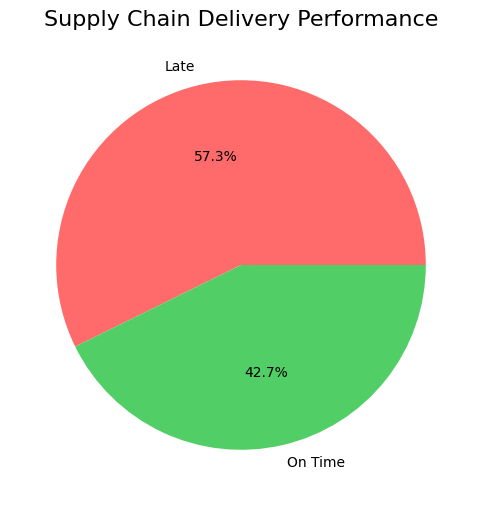

In [8]:
# Create a pie chart of late vs on-time deliveries
plt.figure(figsize=(8, 6))
df['is_late'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ff6b6b', '#51cf66'],
    labels=['Late', 'On Time']
)
plt.title('Supply Chain Delivery Performance', fontsize=16)
plt.ylabel('')
plt.show()


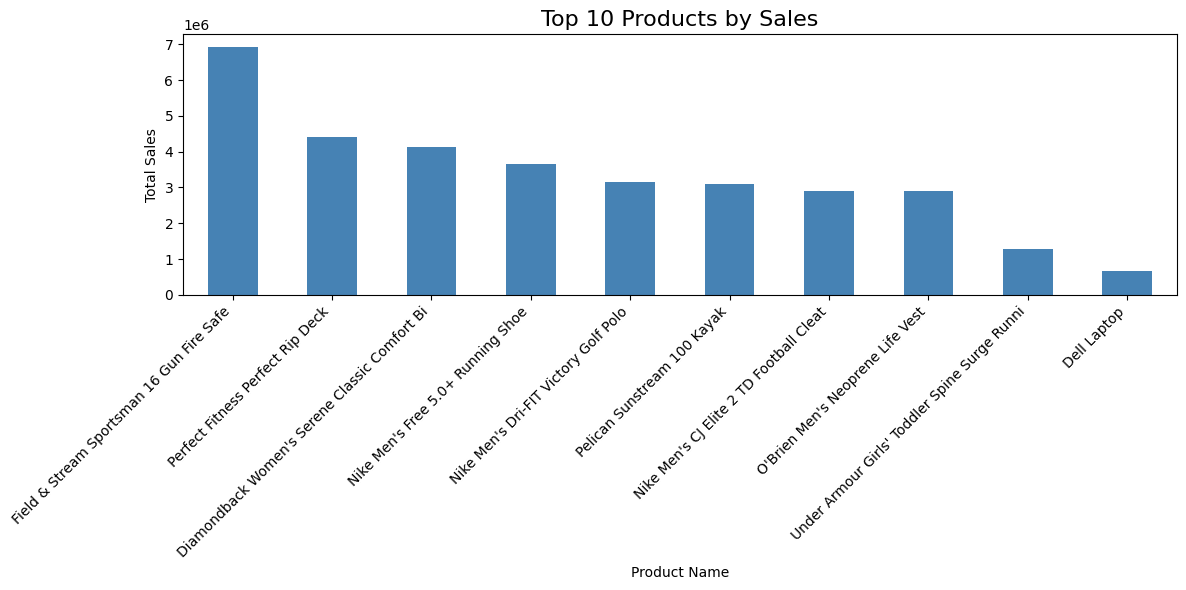

In [9]:
# Top 10 products by sales
plt.figure(figsize=(12, 6))
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', color='steelblue')
plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

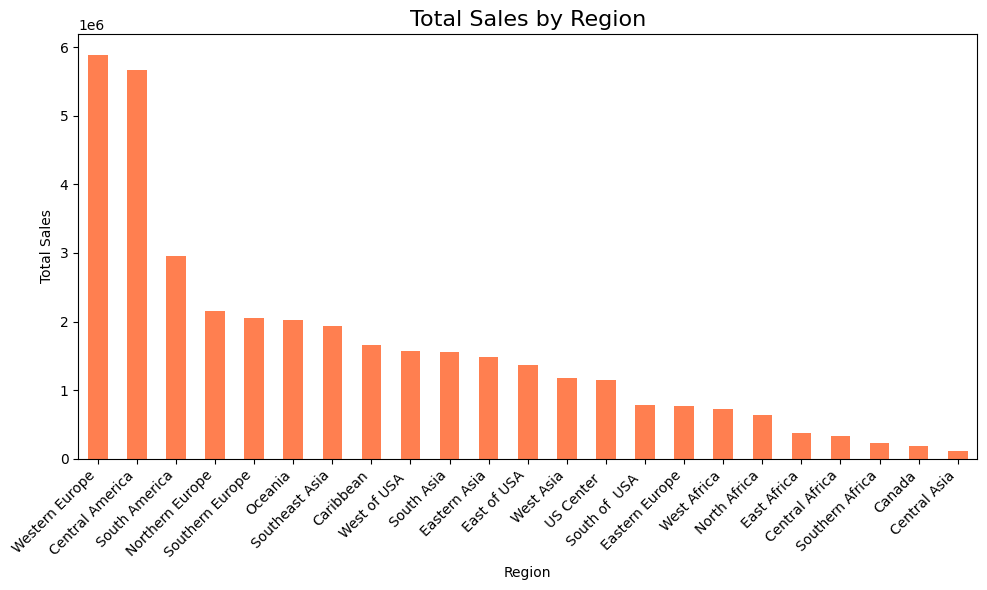


Sales by Region:
Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Eastern Asia       1.486401e+06
East of USA        1.371112e+06
West Asia          1.174672e+06
US Center          1.151356e+06
South of  USA      7.857839e+05
Eastern Europe     7.742666e+05
West Africa        7.279512e+05
North Africa       6.347522e+05
East Africa        3.762349e+05
Central Africa     3.272630e+05
Southern Africa    2.282516e+05
Canada             1.868610e+05
Central Asia       1.098399e+05
Name: Sales, dtype: float64


In [10]:
# Sales by Region
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='coral')
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the numbers too
print("\nSales by Region:")
print(region_sales)